<a href="https://colab.research.google.com/github/TBGhorbanpour/Social-Awareness/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import torch
from transformers import pipeline
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# ==========================================
# 1. Configuration & Device Check
# ==========================================
# Use the latest cleaned CSV from your previous step
INPUT_CSV = OUTPUT_CSV = '/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_NER_Output3.csv'
OUTPUT_CSV = '/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Sentiment_Output.csv'

# Force GPU usage if available (Colab T4/A100)
device = 0 if torch.cuda.is_available() else -1
print(f"🚀 Using device: {'GPU (CUDA)' if device == 0 else 'CPU (Warning: This will be very slow!)'}")

# ==========================================
# 2. Load Data
# ==========================================
print("Loading dataset...")
data = pd.read_csv(INPUT_CSV)

# Ensure we have clean strings and handle NaNs safely
# Using 'bert_ready_tweets' as requested
texts = data['FormalTweet'].fillna('').astype(str).tolist()
print(f"Loaded {len(texts)} tweets for sentiment analysis.")

# ==========================================
# 3. Initialize Batched Sentiment Pipeline
# ==========================================
print("Loading ParsBERT Sentiment model...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="HooshvareLab/bert-fa-base-uncased-sentiment-deepsentipers-multi",
    tokenizer="HooshvareLab/bert-fa-base-uncased-sentiment-deepsentipers-multi",
    device=device,
    batch_size=16  # Process 16 tweets at a time (Lower to 8 if you get CUDA Out of Memory)
    # Note: truncation/max_length omitted to prevent the _sanitize_parameters TypeError.
    # Tweets are naturally short and will safely fit within BERT's default 512 limit.
)

# ==========================================
# 4. Run Inference (Fast!)
# ==========================================
print("Starting batched sentiment analysis... (This will take ~10-15 mins on GPU)")
sentiment_results = sentiment_pipeline(texts)

# ==========================================
# 5. Format and Save Results
# ==========================================
print("Formatting results...")

# The pipeline returns a list of dicts: [{'label': 'positive', 'score': 0.95}, ...]
# We extract these directly into two new columns efficiently using list comprehensions
data['sentiment_label'] = [res['label'] for res in sentiment_results]
data['confidence_score'] = [res['score'] for res in sentiment_results]

# Save to Drive
data.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"✅ Done! Saved sentiment results to {OUTPUT_CSV}")

# Display Preview and Distribution
print("\n📊 Sentiment Distribution:")
print(data['sentiment_label'].value_counts())

print("\n👀 Preview:")
display_cols = ['FormalTweet', 'sentiment_label', 'confidence_score']
display(data[display_cols].head(5))

🚀 Using device: GPU (CUDA)
Loading dataset...
Loaded 75455 tweets for sentiment analysis.
Loading ParsBERT Sentiment model...


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  651MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Starting batched sentiment analysis... (This will take ~10-15 mins on GPU)
Formatting results...
✅ Done! Saved sentiment results to /content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Sentiment_Output.csv

📊 Sentiment Distribution:
sentiment_label
furious      25331
neutral      19921
happy        14231
angry        10805
delighted     5167
Name: count, dtype: int64

👀 Preview:


,FormalTweet,sentiment_label,confidence_score
0,نان توموشی بارش بندر عالی میفهمند خاک هرمز ما...,delighted,0.949858
1,سرنج معنی خاک سرخ وایب هرمز,neutral,0.993631
2,خاک خاک جزیره ی هرمز,neutral,0.994319
3,مست زمین خورده کاس هرمز خون دل نوشروان رفتند ...,delighted,0.344084
4,قطار بروی بندر عباس لنج بروی جزیره کیش قشم هر...,delighted,0.560215


In [ ]:
import pandas as pd
import ast

data = pd.read_csv('/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Sentiment_Output.csv')

# Convert string back to list
data['cities_list'] = data['cities'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Explode to see individual extracted cities
all_extracted_cities = data['cities_list'].explode().value_counts()

# Filter for anything containing "زاینده"
zayandeh_variations = all_extracted_cities[all_extracted_cities.index.str.contains('زاینده', na=False)]
print("Current Zayandeh Rood variations extracted by NER:")
print(zayandeh_variations)

Current Zayandeh Rood variations extracted by NER:
cities_list
زاینده                            922
اصفهان زاینده                     337
زاینده اصفهان                     196
زاینده کارون                       53
رودخانه زاینده                     49
                                 ... 
زاینده دادگستری اصفهان              1
اصفهان زاینده تهران                 1
رودخانه سیدنی زاینده شرف            1
پل زمانخان زاینده زیبا              1
شیراز اصفهان زاینده نظیر پاریس      1
Name: count, Length: 3205, dtype: int64


In [ ]:
import pandas as pd
import ast

# 1. Load the latest dataset
INPUT_CSV = '/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Sentiment_Output.csv'
OUTPUT_CSV = '/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Final_Mapped.csv'
data = pd.read_csv(INPUT_CSV)

# Ensure 'cities' is a proper Python list
data['cities_list'] = data['cities'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. Comprehensive Location Mapping Dictionary
location_mapping = {
    # ==========================================
    # Isfahan Mappings
    # ==========================================
    'اصفهان': 'اصفهان', 'اص_فهان': 'اصفهان', 'استان اصفهان': 'اصفهان',
    'زایندهرود': 'اصفهان', 'زاینده_رود': 'اصفهان', 'زاینده رود': 'اصفهان', 'زاینده _': 'اصفهان', 'زاینده': 'اصفهان',
    'اصفهان زایندهرود': 'اصفهان', 'زایندهرود اصفهان': 'اصفهان', 'اصفهان زاینده _': 'اصفهان',
    'ورزنه': 'اصفهان', 'کویر ورزنه': 'اصفهان', 'تالاب گاوخونی': 'اصفهان', 'گاوخونی': 'اصفهان',
    'کاشان': 'اصفهان', 'نایین': 'اصفهان', 'خمینی شهر': 'اصفهان', 'نجف آباد': 'اصفهان',
    'شهرضا': 'اصفهان', 'فلاورجان': 'اصفهان', 'لنجان': 'اصفهان', 'مبارکه': 'اصفهان',

    # ==========================================
    # Urmia Mappings
    # ==========================================
    'ارومیه': 'ارومیه', 'اورمیه': 'ارومیه', 'ار_ومیه': 'ارومیه', 'استان ارومیه': 'ارومیه',
    'دریاچه ارومیه': 'ارومیه', 'دریاچه_ارومیه': 'ارومیه', 'دریاچه _ ارومیه': 'ارومیه', 'ارومیه دریاچه': 'ارومیه',
    'دریاچه اورمیه': 'ارومیه', 'اورمیه دریاچه': 'ارومیه',
    'شاهین دژ': 'ارومیه', 'مهاباد': 'ارومیه', 'بوکان': 'ارومیه', 'پیرانشهر': 'ارومیه', 'نقده': 'ارومیه',
    'میاندوآب': 'ارومیه', 'سلماس': 'ارومیه', 'خوی': 'ارومیه', 'ماکو': 'ارومیه', 'چالدران': 'ارومیه',

    # ==========================================
    # Khuzestan Mappings
    # ==========================================
    'خوزستان': 'خوزستان', 'خوز_ستان': 'خوزستان', 'استان خوزستان': 'خوزستان',
    'اهواز': 'خوزستان', 'کارون': 'خوزستان', 'کرخه': 'خوزستان', 'دز': 'خوزستان',
    'آبادان': 'خوزستان', 'خرمشهر': 'خوزستان', 'دزفول': 'خوزستان', 'ماهشهر': 'خوزستان',
    'بندر ماهشهر': 'خوزستان', 'پتروشیمی ماهشهر': 'خوزستان', 'شادگان': 'خوزستان', 'تالاب شادگان': 'خوزستان',
    'هویزه': 'خوزستان', 'تالاب هویزه': 'خوزستان', 'شوش': 'خوزستان', 'شوشتر': 'خوزستان',
    'مسجدسلیمان': 'خوزستان', 'بهبهان': 'خوزستان', 'ایذه': 'خوزستان', 'رامهرمز': 'خوزستان',

    # ==========================================
    # Tehran Mappings
    # ==========================================
    'تهران': 'تهران', 'طهران': 'تهران', 'ت_هران': 'تهران', 'استان تهران': 'تهران',
    'شهرری': 'تهران', 'ری': 'تهران', 'اسلامشهر': 'تهران', 'ورامین': 'تهران',
    'دماوند': 'تهران', 'تجریش': 'تهران', 'ونک': 'تهران', 'سعادت آباد': 'تهران', 'پونک': 'تهران',
    'زعفرانیه': 'تهران', 'الهیه': 'تهران', 'اقدسیه': 'تهران', 'درکه': 'تهران', 'دربند': 'تهران',
    'توچال': 'تهران', 'برج میلاد': 'تهران', 'میلاد': 'تهران', 'برج آزادی': 'تهران', 'میدان آزادی': 'تهران'
}

# 3. Mapping Function (Prevents Duplicates in the same row)
def map_cities(city_list):
    if not isinstance(city_list, list):
        return []

    mapped_cities = []
    for city in city_list:
        city = str(city).strip()
        if city in location_mapping:
            mapped_cities.append(location_mapping[city])
        else:
            mapped_cities.append(city)

    # PREVENT DUPLICATES: Convert to set and back to list to ensure unique cities per tweet
    return list(set(mapped_cities))

# Apply mapping
data['mapped_cities'] = data['cities_list'].apply(map_cities)

# 4. Explode and Analyze
exploded = data.explode('mapped_cities')
target_cities = ['ارومیه', 'اصفهان', 'خوزستان', 'تهران']

print("📊 Final Sentiment Analysis with Comprehensive Mapping:\n" + "="*50)

for city_fa in target_cities:
    sub = exploded[(exploded['mapped_cities'] == city_fa) & (exploded['mapped_cities'].notna())]
    total_tweets = len(sub)

    print(f"\n📍 {city_fa} (Total Unique Tweets: {total_tweets})")

    if total_tweets > 0:
        sentiment_dist = sub['sentiment_label'].value_counts()
        sentiment_pct = (sentiment_dist / total_tweets * 100).round(1)

        for label, count in sentiment_dist.items():
            pct = sentiment_pct[label]
            print(f"   ├─ {label}: {count} tweets ({pct}%)")
    else:
        print("   └─ No tweets found.")

# 5. Save the final processed dataset to CSV
data.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"\n✅ Final dataset with mapped cities saved to: {OUTPUT_CSV}")

📊 Final Sentiment Analysis with Comprehensive Mapping:

📍 ارومیه (Total Unique Tweets: 2626)
   ├─ neutral: 1019 tweets (38.8%)
   ├─ angry: 589 tweets (22.4%)
   ├─ furious: 495 tweets (18.8%)
   ├─ happy: 432 tweets (16.5%)
   ├─ delighted: 91 tweets (3.5%)

📍 اصفهان (Total Unique Tweets: 2099)
   ├─ neutral: 592 tweets (28.2%)
   ├─ furious: 555 tweets (26.4%)
   ├─ happy: 503 tweets (24.0%)
   ├─ angry: 345 tweets (16.4%)
   ├─ delighted: 104 tweets (5.0%)

📍 خوزستان (Total Unique Tweets: 1162)
   ├─ neutral: 388 tweets (33.4%)
   ├─ furious: 258 tweets (22.2%)
   ├─ happy: 224 tweets (19.3%)
   ├─ angry: 214 tweets (18.4%)
   ├─ delighted: 78 tweets (6.7%)

📍 تهران (Total Unique Tweets: 778)
   ├─ furious: 237 tweets (30.5%)
   ├─ angry: 230 tweets (29.6%)
   ├─ neutral: 214 tweets (27.5%)
   ├─ happy: 76 tweets (9.8%)
   ├─ delighted: 21 tweets (2.7%)

✅ Final dataset with mapped cities saved to: /content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Final_Mapped.csv


In [ ]:
import pandas as pd
import ast

# 1. Load your latest processed dataset
INPUT_CSV = '/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Sentiment_Output.csv'
SUMMARY_CSV = '/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_City_Sentiment_Summary.csv'

data = pd.read_csv(INPUT_CSV)

# Ensure 'cities' is a proper Python list
data['cities_list'] = data['cities'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. Location Mapping Dictionary
location_mapping = {
    'زایندهرود': 'اصفهان', 'زاینده_رود': 'اصفهان', 'زاینده رود': 'اصفهان', 'زاینده _': 'اصفهان', 'زاینده': 'اصفهان',
    'اصفهان زایندهرود': 'اصفهان', 'زایندهرود اصفهان': 'اصفهان', 'اصفهان زاینده _': 'اصفهان', 'اصفهان': 'اصفهان',
    'دریاچه ارومیه': 'ارومیه', 'دریاچه_ارومیه': 'ارومیه', 'دریاچه _ ارومیه': 'ارومیه', 'ارومیه': 'ارومیه', 'اورمیه': 'ارومیه',
    'خوزستان': 'خوزستان', 'اهواز': 'خوزستان', 'کارون': 'خوزستان', 'آبادان': 'خوزستان', 'دزفول': 'خوزستان', 'ماهشهر': 'خوزستان',
    'تهران': 'تهران', 'کرج': 'تهران', 'برج میلاد': 'تهران', 'میدان آزادی': 'تهران'
}

# 3. Map and remove duplicates per row
def map_cities(city_list):
    if not isinstance(city_list, list): return []
    mapped = [location_mapping.get(str(c).strip(), str(c).strip()) for c in city_list]
    return list(set(mapped))

data['mapped_cities'] = data['cities_list'].apply(map_cities)

# 4. Explode and Calculate Summary
exploded = data.explode('mapped_cities')
target_cities = ['ارومیه', 'اصفهان', 'خوزستان', 'تهران']

summary_data = []

for city_fa in target_cities:
    # Get all tweets for this city
    sub = exploded[(exploded['mapped_cities'] == city_fa) & (exploded['mapped_cities'].notna())]
    total_tweets_in_city = len(sub)

    # Drop rows where sentiment is NaN to get accurate denominator
    valid_sub = sub.dropna(subset=['sentiment_label'])
    total_classified = len(valid_sub)

    if total_classified > 0:
        sentiment_dist = valid_sub['sentiment_label'].value_counts()

        # FIX: Divide by total_classified (sum of counts) so percentages equal exactly 100%
        sentiment_pct = (sentiment_dist / total_classified * 100).round(1)

        for label, count in sentiment_dist.items():
            pct = sentiment_pct[label]
            summary_data.append({
                'City': city_fa,
                'Total_Tweets_of_City': total_tweets_in_city,
                'Classified_Tweets': total_classified,
                'Sentiment_Label': label,
                'Count': int(count),
                'Percentage': float(pct)
            })

# 5. Save ONLY the summary to CSV
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(SUMMARY_CSV, index=False, encoding='utf-8-sig')

print(f"✅ City Sentiment Summary successfully saved to:\n{SUMMARY_CSV}")
print("\nPreview of the saved file:")
print(summary_df.to_string(index=False))

✅ City Sentiment Summary successfully saved to:
/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_City_Sentiment_Summary.csv

Preview of the saved file:
   City  Total_Tweets_of_City  Classified_Tweets Sentiment_Label  Count  Percentage
 ارومیه                  2613               2613         neutral   1012        38.7
 ارومیه                  2613               2613           angry    589        22.5
 ارومیه                  2613               2613         furious    492        18.8
 ارومیه                  2613               2613           happy    431        16.5
 ارومیه                  2613               2613       delighted     89         3.4
 اصفهان                  2040               2040         neutral    569        27.9
 اصفهان                  2040               2040         furious    537        26.3
 اصفهان                  2040               2040           happy    499        24.5
 اصفهان                  2040               2040           angry    335        1

**Sentiment Distribution**

In [ ]:
import pandas as pd

# 1. Get the raw counts
counts = data['sentiment_label'].value_counts()
print("--- Raw Counts ---")
print(counts)

# 2. Get the percentages
percentages = data['sentiment_label'].value_counts(normalize=True) * 100
print("\n--- Percentages ---")
print(percentages.round(2))

# 3. Combine them into a single clean summary table
summary = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(2)
})
print("\n--- Summary Table ---")
print(summary)

# 4. Check for missing values (NaNs) just to be safe
missing = data['sentiment_label'].isnull().sum()
print(f"\nMissing values in sentiment_label: {missing}")

--- Raw Counts ---
sentiment_label
furious      25331
neutral      19921
happy        14231
angry        10805
delighted     5167
Name: count, dtype: int64

--- Percentages ---
sentiment_label
furious      33.57
neutral      26.40
happy        18.86
angry        14.32
delighted     6.85
Name: proportion, dtype: float64

--- Summary Table ---
                 Count  Percentage (%)
sentiment_label                       
furious          25331           33.57
neutral          19921           26.40
happy            14231           18.86
angry            10805           14.32
delighted         5167            6.85

Missing values in sentiment_label: 0


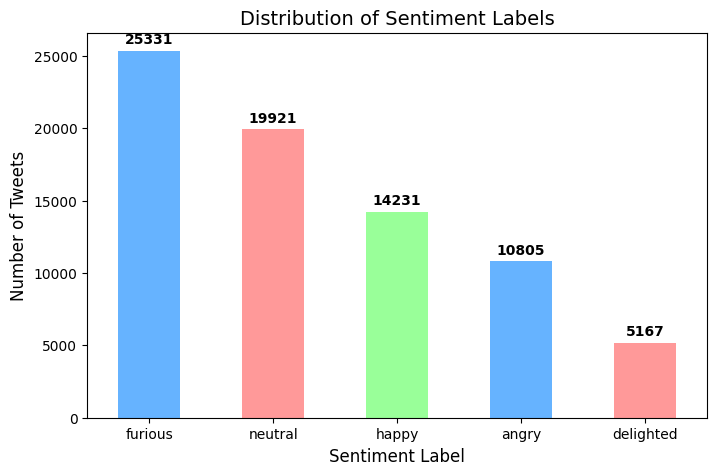

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Create a bar chart
data['sentiment_label'].value_counts().plot(
    kind='bar',
    color=['#66b3ff', '#ff9999', '#99ff99']
)

plt.title('Distribution of Sentiment Labels', fontsize=14)
plt.xlabel('Sentiment Label', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=0) # Keep x-axis labels horizontal

# Add the exact numbers on top of the bars
for i, val in enumerate(data['sentiment_label'].value_counts().values):
    plt.text(i, val + 500, str(val), ha='center', fontweight='bold')

plt.show()

In [ ]:
SUMMARY_CSV = '/content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Sentiment_Distribution_Summary.csv'

summary.to_csv(SUMMARY_CSV, index=True, encoding='utf-8-sig')

print(f"✅ Successfully saved sentiment distribution summary to: {SUMMARY_CSV}")

✅ Successfully saved sentiment distribution summary to: /content/drive/MyDrive/Thesis/Data/Data/Data_Paper/Political_Sentiment_Distribution_Summary.csv
